## 贝叶斯定理回顾

- P(Y)先验概率（prior）- 看到数据前对类别的信念
- P(X|Y)似然概率（likelihood）- 给定类别下特征的概率
- P(Y|X) 后验概率（posterior）- 看到数据后类别的概率

## 朴素贝叶斯的核心假设

特征条件独立（朴素含义）

P(X1,X2,...,Xn|Y) = P(X1|Y) * P(X2|Y) * ... * P(Xn|Y)


## 核心公式
|公式部分|数学表达|侦探类比|
|-----|-----|----------|
|先验概率|P(A)|案发前对凶手的怀疑程度|
|似然概率|P(B\|A)|如果A是凶手，看到证据B的可能性|
|后验概率|P(A\|B)|看到证据后，更新对A的怀疑


**计算过程**

### 第1步：计算先验概率 P(Y)


P(Y=0) = 40/120 = 0.333

P(Y=1) = 41/120 = 0.342

P(Y=2) = 39/120 = 0.325



### 第2步：计算条件概率参数 P(X|Y)


- 似然概率（用高斯分布计算） 

(σ（小写西格玛）通常表示 总体标准差, 而 s 通常表示 样本标准差, 代码中的 std 正是对应数学符号 σ)

mean = stats[c]['mean'] 

$$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i$$

std = stats[c]['std'] 

$$\sigma = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \mu)^2}{n - 1}}$$

- 高斯公式

exponent = -((petal_length - mean) ** 2) / (2 * std ** 2)

likelihood = (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(exponent)

$$\text{P(x|Y)} = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{(x - \mu)^2}{2\sigma^2}}$$

类别 0:
  
  P(X1|Y=0) ~ N(μ=4.99, σ=0.35)

  P(X2|Y=0) ~ N(μ=3.45, σ=0.39)

  P(X3|Y=0) ~ N(μ=1.45, σ=0.18)
  
  P(X4|Y=0) ~ N(μ=0.24, σ=0.10)


### 第3步: 后验概率（未归一化）
        posterior = prior * likelihood
        posteriors[c] = posterior
  

## sample in lives
|场景|先验|新证据|后验（更新后）|
|-----|-----|-----|-----|
|相亲|觉得这个人还行|聊天中发现三观很合|好感大增|
|买股票|看好某公司|财报超预期|更加看好|
|看病|觉得自己健康|体检某项指标偏高|开始担心|
|找工作|觉得自己适合|面试感觉不好|信心下降|

In [7]:
# 理解贝叶斯公式

# 代码模拟
total_days = 1000
rain_days = 300      # 30%下雨
sunny_days = 700     # 70%晴天

# 乌云概率
clouds_when_rain = 0.8    # 下雨时80%乌云
clouds_when_sunny = 0.1   # 晴天时10%乌云

# 计算
rain_and_clouds = rain_days * clouds_when_rain        # 240天
sunny_and_clouds = sunny_days * clouds_when_sunny     # 70天
total_clouds = rain_and_clouds + sunny_and_clouds     # 310天

# 看到乌云时下雨的概率
prob = rain_and_clouds / total_clouds
print(f"看到乌云时下雨的概率: {prob:.1%}")  # 77.4%

看到乌云时下雨的概率: 77.4%


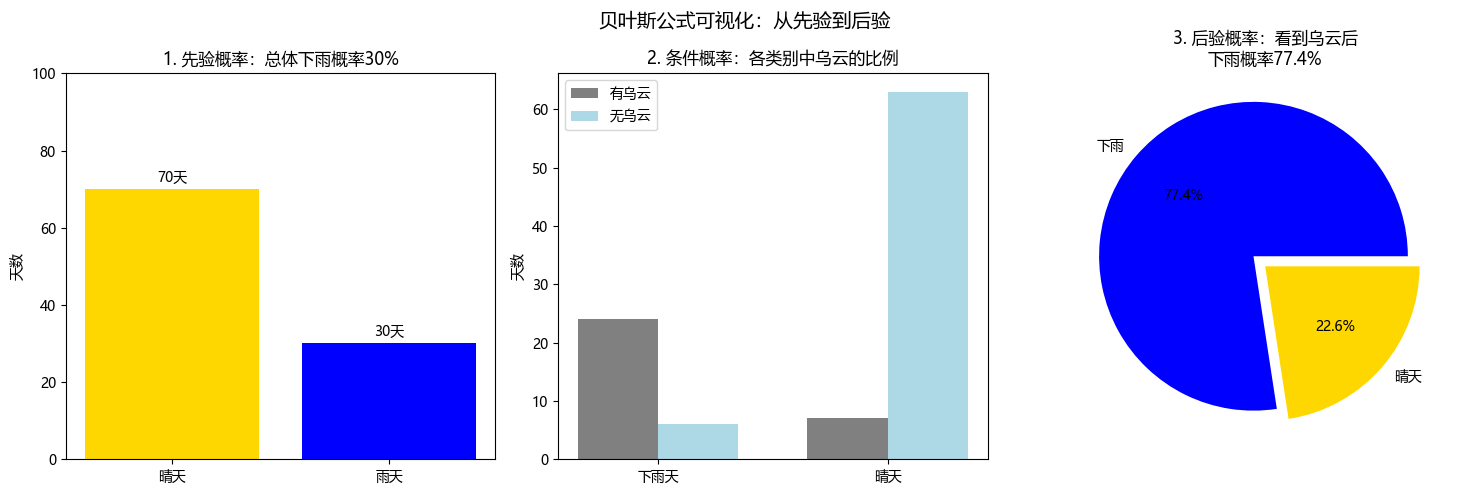

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import numpy as np

def visualize_bayes():
    """可视化贝叶斯公式"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 图1：先验概率（总体情况）
    ax1 = axes[0]
    total = 100
    rain = 30
    sunny = 70
    
    ax1.bar(['晴天', '雨天'], [sunny, rain], color=['gold', 'blue'])
    ax1.set_ylabel('天数')
    ax1.set_title('1. 先验概率：总体下雨概率30%')
    ax1.set_ylim(0, 100)
    for i, v in enumerate([sunny, rain]):
        ax1.text(i, v + 2, f'{v}天', ha='center')
    
    # 图2：条件概率（每个类别下乌云的情况）
    ax2 = axes[1]
    
    # 下雨天
    rain_clouds = 24  # 80% of 30
    rain_no_clouds = 6  # 20% of 30
    
    # 晴天
    sunny_clouds = 7   # 10% of 70
    sunny_no_clouds = 63  # 90% of 70
    
    x = np.arange(2)
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, [rain_clouds, sunny_clouds], 
                    width, label='有乌云', color='gray')
    bars2 = ax2.bar(x + width/2, [rain_no_clouds, sunny_no_clouds], 
                    width, label='无乌云', color='lightblue')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(['下雨天', '晴天'])
    ax2.set_ylabel('天数')
    ax2.set_title('2. 条件概率：各类别中乌云的比例')
    ax2.legend()
    
    # 图3：后验概率（看到乌云后）
    ax3 = axes[2]
    total_clouds = rain_clouds + sunny_clouds
    prob_rain_given_clouds = rain_clouds / total_clouds
    prob_sunny_given_clouds = sunny_clouds / total_clouds
    
    ax3.pie([prob_rain_given_clouds, prob_sunny_given_clouds], 
            labels=['下雨', '晴天'],
            colors=['blue', 'gold'],
            autopct='%1.1f%%',
            explode=(0.1, 0))
    ax3.set_title(f'3. 后验概率：看到乌云后\n下雨概率{prob_rain_given_clouds:.1%}')
    
    plt.suptitle('贝叶斯公式可视化：从先验到后验', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_bayes()

In [9]:
def disease_test_example():
    """疾病检测例子 - 最经典的贝叶斯应用"""
    print("="*50)
    print("疾病检测例子")
    print("="*50)
    
    # 已知信息
    disease_rate = 0.001  # 患病率：0.1%（1000人中1人患病）
    test_accuracy = 0.99  # 检测准确率：99%
    false_positive = 0.05  # 误报率：5%
    
    print(f"背景信息:")
    print(f"  - 患病率: {disease_rate*100}%")
    print(f"  - 检测准确率: {test_accuracy*100}%")
    print(f"  - 误报率: {false_positive*100}%")
    
    # 用100000人计算
    population = 100000
    sick = int(population * disease_rate)  # 100人患病
    healthy = population - sick            # 99900人健康
    
    print(f"\n用{population}人计算:")
    print(f"  - 实际患病: {sick}人")
    print(f"  - 实际健康: {healthy}人")
    
    # 检测结果
    sick_test_positive = sick * test_accuracy        # 99人真阳性
    sick_test_negative = sick - sick_test_positive   # 1人假阴性
    
    healthy_test_positive = healthy * false_positive  # 4995人假阳性
    healthy_test_negative = healthy - healthy_test_positive  # 94905人真阴性
    
    print(f"\n检测结果:")
    print(f"  - 真阳性（患病且检出）: {sick_test_positive}人")
    print(f"  - 假阴性（患病未检出）: {sick_test_negative}人")
    print(f"  - 真阴性（健康未检出）: {healthy_test_negative}人")
    print(f"  - 假阳性（健康被误报）: {healthy_test_positive}人")
    
    # 关键问题：检测阳性，实际患病的概率？
    total_positive = sick_test_positive + healthy_test_positive
    prob = sick_test_positive / total_positive
    
    print(f"\n🔑 核心问题：")
    print(f"如果检测结果是阳性，实际患病的概率是多少？")
    print(f"  = 真阳性 / (真阳性 + 假阳性)")
    print(f"  = {sick_test_positive} / ({sick_test_positive} + {healthy_test_positive})")
    print(f"  = {sick_test_positive} / {total_positive}")
    print(f"  = {prob:.1%}")
    
    print(f"\n💡 惊人发现：即使检测准确率99%，阳性结果也只有{prob:.1%}的概率患病！")
    print(f"   原因：患病率太低，假阳性数量远超真阳性")
    
    return prob

disease_test_example()

疾病检测例子
背景信息:
  - 患病率: 0.1%
  - 检测准确率: 99.0%
  - 误报率: 5.0%

用100000人计算:
  - 实际患病: 100人
  - 实际健康: 99900人

检测结果:
  - 真阳性（患病且检出）: 99.0人
  - 假阴性（患病未检出）: 1.0人
  - 真阴性（健康未检出）: 94905.0人
  - 假阳性（健康被误报）: 4995.0人

🔑 核心问题：
如果检测结果是阳性，实际患病的概率是多少？
  = 真阳性 / (真阳性 + 假阳性)
  = 99.0 / (99.0 + 4995.0)
  = 99.0 / 5094.0
  = 1.9%

💡 惊人发现：即使检测准确率99%，阳性结果也只有1.9%的概率患病！
   原因：患病率太低，假阳性数量远超真阳性


0.019434628975265017

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from scipy.stats import norm
import matplotlib.pyplot as plt

import platform

def set_chinese_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS']
    else:  # Linux
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

set_chinese_font() 

class NaiveBayes:
    """朴素贝叶斯分类器（高斯版本，适用于连续特征）"""
    
    def __init__(self):
        self.classes = None           # 所有类别
        self.prior_probs = {}         # 先验概率 P(Y)
        self.mean_std = {}            # 每个类别下每个特征的均值和标准差
        self.class_priors = {}        # 类别先验（用于预测）
        
    def fit(self, X, y):
        """
        训练朴素贝叶斯模型
        步骤1: 计算先验概率 P(Y)
        步骤2: 计算条件概率 P(X|Y)的参数（均值和标准差）
        """
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        
        # 第1步：计算先验概率 P(Y=c)
        print("="*50)
        print("第1步：计算先验概率 P(Y)")
        print("="*50)
        
        for c in self.classes:
            # 统计每个类别的样本数
            n_c = np.sum(y == c)
            # 先验概率 = 类别样本数 / 总样本数
            prior = n_c / n_samples
            self.prior_probs[c] = prior
            print(f"P(Y={c}) = {n_c}/{n_samples} = {prior:.3f}")
        
        # 第2步：计算条件概率 P(X|Y) 的参数
        print("\n" + "="*50)
        print("第2步：计算条件概率参数 P(X|Y)")
        print("="*50)
        
        self.mean_std = {}
        for c in self.classes:
            # 获取当前类别的所有样本
            X_c = X[y == c]
            
            # 计算每个特征的均值和标准差
            mean_c = np.mean(X_c, axis=0)
            std_c = np.std(X_c, axis=0)
            
            self.mean_std[c] = {
                'mean': mean_c,
                'std': std_c
            }
            
            print(f"\n类别 {c}:")
            for feature_idx in range(len(mean_c)):
                print(f"  P(X{feature_idx+1}|Y={c}) ~ N(μ={mean_c[feature_idx]:.2f}, "
                      f"σ={std_c[feature_idx]:.2f})")
        
        print("\n训练完成！")
    
    def gaussian_pdf(self, x, mean, std):
        """
        高斯概率密度函数
        计算 P(x|Y) = 1/(√(2π)σ) * exp(-(x-μ)²/(2σ²))
        """
        # 避免除以0
        if std == 0:
            std = 1e-6
        
        exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
        coefficient = 1 / (np.sqrt(2 * np.pi) * std)
        
        return coefficient * exponent
    
    def predict_proba(self, X):
        """
        预测每个类别的后验概率
        第3步：使用贝叶斯定理预测
        """
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        
        probabilities = np.zeros((n_samples, n_classes))
        
        print("\n" + "="*50)
        print("第3步：使用贝叶斯定理预测")
        print("="*50)
        
        for i, sample in enumerate(X):
            print(f"\n样本 {i+1}: {sample}")
            
            posteriors = {}
            for c in self.classes:
                # 先验概率
                prior = self.prior_probs[c]
                
                # 似然概率（条件独立乘积）
                likelihood = 1.0
                mean_c = self.mean_std[c]['mean']
                std_c = self.mean_std[c]['std']
                
                print(f"  计算 P(Y={c}|X):")
                print(f"    先验 P(Y={c}) = {prior:.4f}")
                
                for j, x_j in enumerate(sample):
                    # 计算 P(x_j|Y=c)
                    cond_prob = self.gaussian_pdf(x_j, mean_c[j], std_c[j])
                    likelihood *= cond_prob
                    print(f"    P(X{j+1}={x_j:.2f}|Y={c}) = {cond_prob:.4f}")
                
                # 后验概率（归一化前）
                posterior = prior * likelihood
                posteriors[c] = posterior
                print(f"    后验（未归一化）= {prior:.4f} × {likelihood:.4f} = {posterior:.4f}")
            
            # 归一化得到真正的后验概率
            total = sum(posteriors.values())
            for c in self.classes:
                probabilities[i, c] = posteriors[c] / total
            
            print(f"    归一化后概率: { {c: prob/total for c, prob in posteriors.items()} }")
        
        return probabilities
    
    def predict(self, X):
        """预测类别（最大后验概率）"""
        probas = self.predict_proba(X)
        predictions = self.classes[np.argmax(probas, axis=1)]
        return predictions
    
    def score(self, X, y):
        """计算准确率"""
        predictions = self.predict(X)
        return np.mean(predictions == y)

# 加载数据
iris = load_iris()
X, y = iris.data, iris.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("鸢尾花数据集信息:")
print(f"特征: {iris.feature_names}")
print(f"类别: {iris.target_names}")
print(f"训练集: {X_train.shape[0]}个样本")
print(f"测试集: {X_test.shape[0]}个样本\n")

# 训练模型
nb = NaiveBayes()
nb.fit(X_train, y_train)

# 预测
print("\n" + "="*50)
print("预测新样本")
print("="*50)
predictions = nb.predict(X_test)
accuracy = nb.score(X_test, y_test)

print(f"\n模型准确率: {accuracy:.2f}")

鸢尾花数据集信息:
特征: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别: ['setosa' 'versicolor' 'virginica']
训练集: 120个样本
测试集: 30个样本

第1步：计算先验概率 P(Y)
P(Y=0) = 40/120 = 0.333
P(Y=1) = 41/120 = 0.342
P(Y=2) = 39/120 = 0.325

第2步：计算条件概率参数 P(X|Y)

类别 0:
  P(X1|Y=0) ~ N(μ=4.99, σ=0.35)
  P(X2|Y=0) ~ N(μ=3.45, σ=0.39)
  P(X3|Y=0) ~ N(μ=1.45, σ=0.18)
  P(X4|Y=0) ~ N(μ=0.24, σ=0.10)

类别 1:
  P(X1|Y=1) ~ N(μ=5.92, σ=0.54)
  P(X2|Y=1) ~ N(μ=2.77, σ=0.32)
  P(X3|Y=1) ~ N(μ=4.24, σ=0.48)
  P(X4|Y=1) ~ N(μ=1.32, σ=0.20)

类别 2:
  P(X1|Y=2) ~ N(μ=6.53, σ=0.65)
  P(X2|Y=2) ~ N(μ=2.97, σ=0.31)
  P(X3|Y=2) ~ N(μ=5.52, σ=0.53)
  P(X4|Y=2) ~ N(μ=2.00, σ=0.29)

训练完成！

预测新样本

第3步：使用贝叶斯定理预测

样本 1: [6.1 2.8 4.7 1.2]
  计算 P(Y=0|X):
    先验 P(Y=0) = 0.3333
    P(X1=6.10|Y=0) = 0.0079
    P(X2=2.80|Y=0) = 0.2529
    P(X3=4.70|Y=0) = 0.0000
    P(X4=1.20|Y=0) = 0.0000
    后验（未归一化）= 0.3333 × 0.0000 = 0.0000
  计算 P(Y=1|X):
    先验 P(Y=1) = 0.3417
    P(X1=6.10|Y=1) = 0.7037
    P(X2=2.80|Y=

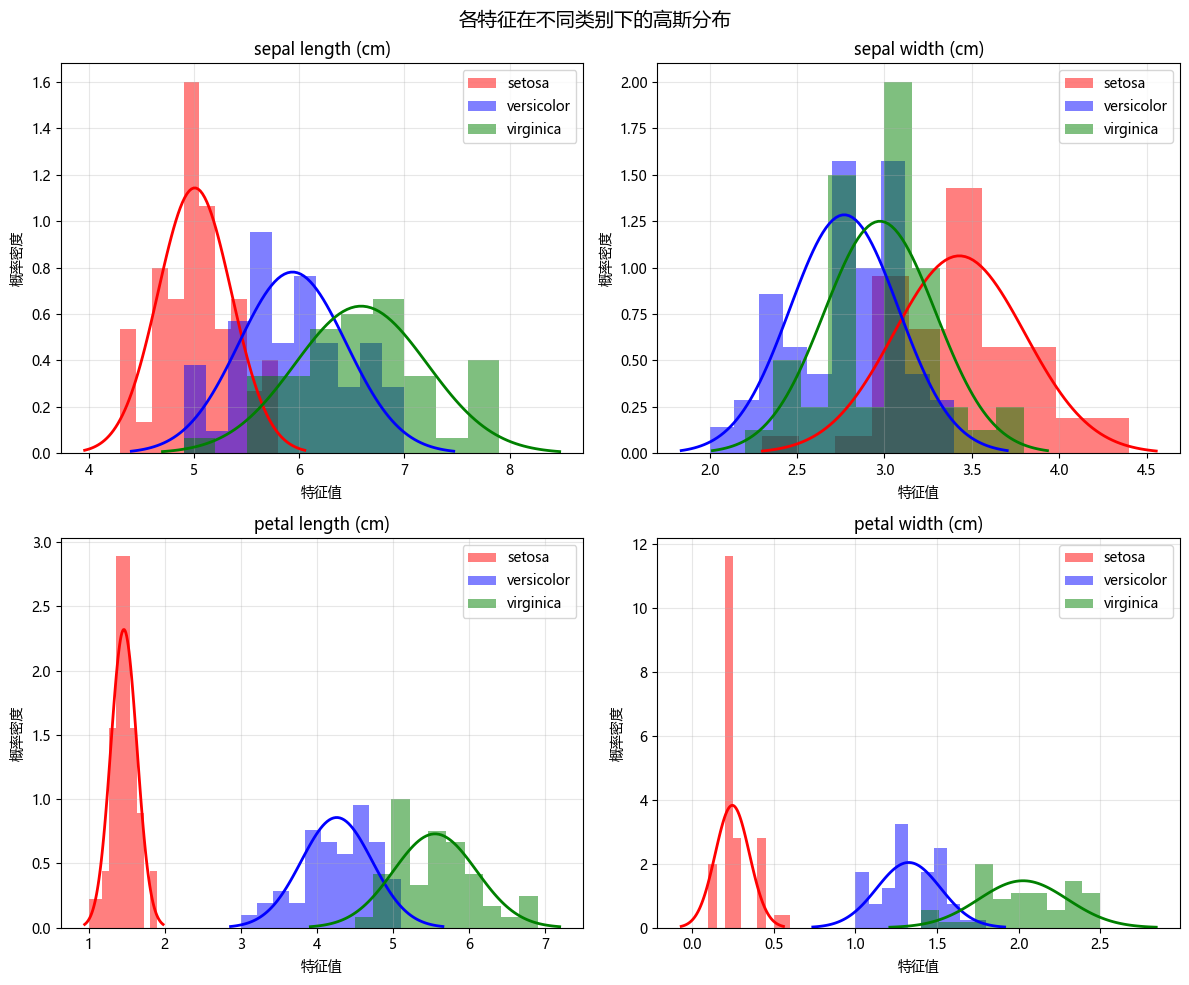

In [4]:
def plot_feature_distributions():
    """可视化每个类别下特征的分布"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    feature_names = iris.feature_names
    target_names = iris.target_names
    
    colors = ['red', 'blue', 'green']
    
    for i, ax in enumerate(axes.flat):
        for c in range(3):
            # 获取当前类别的特征值
            X_c = X[y == c][:, i]
            
            # 绘制直方图
            ax.hist(X_c, bins=10, alpha=0.5, color=colors[c], 
                   label=f'{target_names[c]}', density=True)
            
            # 绘制拟合的高斯曲线
            mu = np.mean(X_c)
            sigma = np.std(X_c)
            x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
            ax.plot(x, norm.pdf(x, mu, sigma), 
                   color=colors[c], linewidth=2)
        
        ax.set_title(feature_names[i])
        ax.set_xlabel('特征值')
        ax.set_ylabel('概率密度')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('各特征在不同类别下的高斯分布', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_feature_distributions()

In [5]:
def manual_naive_bayes_example():
    """手动计算一个简单例子"""
    print("="*60)
    print("手动计算示例：预测一朵新鸢尾花")
    print("="*60)
    
    # 训练数据统计（简化版）
    # 类别: 0=山鸢尾, 1=变色鸢尾, 2=维吉尼亚鸢尾
    
    # 先验概率（基于训练集）
    priors = {
        0: 0.33,  # 33%山鸢尾
        1: 0.33,  # 33%变色鸢尾
        2: 0.34   # 34%维吉尼亚鸢尾
    }
    
    # 每个类别下特征的均值和标准差（以花瓣长度为例）
    # 实际数据基于Iris数据集
    stats = {
        0: {'mean': 1.46, 'std': 0.17},   # 山鸢尾花瓣短
        1: {'mean': 4.26, 'std': 0.47},   # 变色鸢尾花瓣中等
        2: {'mean': 5.55, 'std': 0.55}    # 维吉尼亚鸢尾花瓣长
    }
    
    # 新样本花瓣长度
    petal_length = 3.5
    
    print(f"\n新样本花瓣长度: {petal_length} cm")
    print("\n计算步骤:")
    
    posteriors = {}
    
    for c in [0, 1, 2]:
        # 步骤1: 先验概率
        prior = priors[c]
        
        # 步骤2: 似然概率（用高斯分布计算）
        mean = stats[c]['mean']
        std = stats[c]['std']
        
        # 高斯公式
        exponent = -((petal_length - mean) ** 2) / (2 * std ** 2)
        likelihood = (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(exponent)
        
        # 步骤3: 后验概率（未归一化）
        posterior = prior * likelihood
        posteriors[c] = posterior
        
        print(f"\n类别 {c} ({iris.target_names[c]}):")
        print(f"  P(Y={c}) = {prior}")
        print(f"  P(花瓣长={petal_length}|Y={c}) = {likelihood:.4f}")
        print(f"  后验 = {prior} × {likelihood:.4f} = {posterior:.4f}")
    
    # 归一化
    total = sum(posteriors.values())
    print(f"\n归一化因子: {total:.4f}")
    
    for c in [0, 1, 2]:
        normalized = posteriors[c] / total
        print(f"  P(Y={c}|X) = {normalized:.4f}")
    
    # 预测
    predicted = max(posteriors, key=posteriors.get)
    print(f"\n预测类别: {iris.target_names[predicted]}")
    
    return predicted

manual_naive_bayes_example()

手动计算示例：预测一朵新鸢尾花

新样本花瓣长度: 3.5 cm

计算步骤:

类别 0 (setosa):
  P(Y=0) = 0.33
  P(花瓣长=3.5|Y=0) = 0.0000
  后验 = 0.33 × 0.0000 = 0.0000

类别 1 (versicolor):
  P(Y=1) = 0.33
  P(花瓣长=3.5|Y=1) = 0.2296
  后验 = 0.33 × 0.2296 = 0.0758

类别 2 (virginica):
  P(Y=2) = 0.34
  P(花瓣长=3.5|Y=2) = 0.0007
  后验 = 0.34 × 0.0007 = 0.0002

归一化因子: 0.0760
  P(Y=0|X) = 0.0000
  P(Y=1|X) = 0.9969
  P(Y=2|X) = 0.0031

预测类别: versicolor


1

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

# 使用sklearn的朴素贝叶斯
sklearn_nb = GaussianNB()
sklearn_nb.fit(X_train, y_train)

# 预测
sklearn_pred = sklearn_nb.predict(X_test)
sklearn_accuracy = sklearn_nb.score(X_test, y_test)

print("自定义实现 vs sklearn实现")
print(f"自定义准确率: {accuracy:.3f}")
print(f"sklearn准确率: {sklearn_accuracy:.3f}")

# 详细报告
print("\n分类报告:")
print(classification_report(y_test, sklearn_pred, 
                          target_names=iris.target_names))

# 混淆矩阵
print("混淆矩阵:")
print(confusion_matrix(y_test, sklearn_pred))

自定义实现 vs sklearn实现
自定义准确率: 1.000
sklearn准确率: 1.000

分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

混淆矩阵:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
